# CNN Image Classification: Dogs vs Cats

**Dataset:** Dogs vs Cats (Kaggle) - 20,000 training images, 4,000 validation  
**Model:** Custom 3-block CNN with Batch Normalization, Data Augmentation, and Transfer Learning (MobileNetV2)  


## Setup and Imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from sklearn.metrics import confusion_matrix, classification_report

import kagglehub

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully")

TensorFlow version: 2.21.0
All libraries loaded successfully


## Data Loading and Augmentation


In [2]:
path = kagglehub.dataset_download("princelv84/dogsvscats")
train_dir = os.path.join(path, "train")

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# Augmented training generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2
)

# Validation generator - rescale only
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    seed=42
)

val_data = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    seed=42
)

print(f"Training samples  : {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Classes           : {train_data.class_indices}")

Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Training samples  : 16000
Validation samples: 4000
Classes           : {'cats': 0, 'dogs': 1}


### Sample Images

Visualising a batch of training images to confirm data loading and augmentation are working correctly.

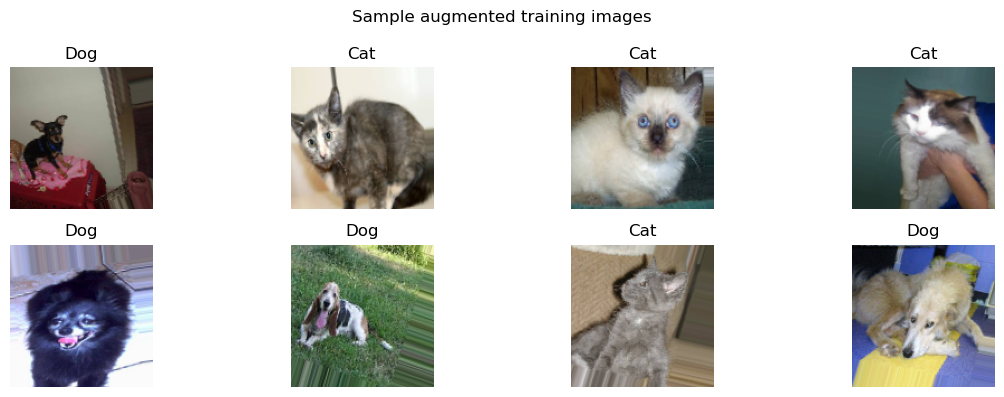

In [3]:
sample_images, sample_labels = next(train_data)

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(sample_images[i])
    label = "Dog" if sample_labels[i] == 1 else "Cat"
    plt.title(label)
    plt.axis("off")
plt.suptitle("Sample augmented training images")
plt.tight_layout()
plt.show()

## Custom CNN Architecture

A 3-block CNN with Conv2D, Batch Normalization, and MaxPooling. Batch Normalization stabilises training  
and improves convergence. Dropout(0.5) reduces overfitting in the dense layers.

In [4]:
def build_custom_cnn():
    model = models.Sequential([
        layers.Input(shape=(128, 128, 3)),

        # Block 1
        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 4
        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

cnn_model = build_custom_cnn()
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       4,194,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,586,177 (17.49 MB)

 Trainable params: 4,584,705 (17.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

## Training with Callbacks

Three callbacks are used:
- **EarlyStopping** - stops training if validation accuracy stops improving for 3 epochs
- **ReduceLROnPlateau** - halves the learning rate when validation loss plateaus
- **ModelCheckpoint** - saves the best model weights automatically

In [5]:
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "best_cnn_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

print("Training Custom CNN...")
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks
)

Training Custom CNN...
Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.6041 - loss: 0.8401  
Epoch 1: val_accuracy improved from None to 0.65025, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 431s 849ms/step - accuracy: 0.6318 - loss: 0.7240 - val_accuracy: 0.6503 - val_loss: 0.6188 - learning_rate: 0.0010
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 757ms/step - accuracy: 0.7014 - loss: 0.5838  
Epoch 2: val_accuracy improved from 0.65025 to 0.74800, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 402s 803ms/step - accuracy: 0.7130 - loss: 0.5632 - val_accuracy: 0.7480 - val_loss: 0.5352 - learning_rate: 0.0010
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 733ms/step - accuracy: 0.7471 - loss: 0.5146  
Epoch 3: val_accuracy improved from 0.74800 to 0.79825, saving model to best_cnn_model.keras

Epoch 3: finished saving mod

### Training Curves

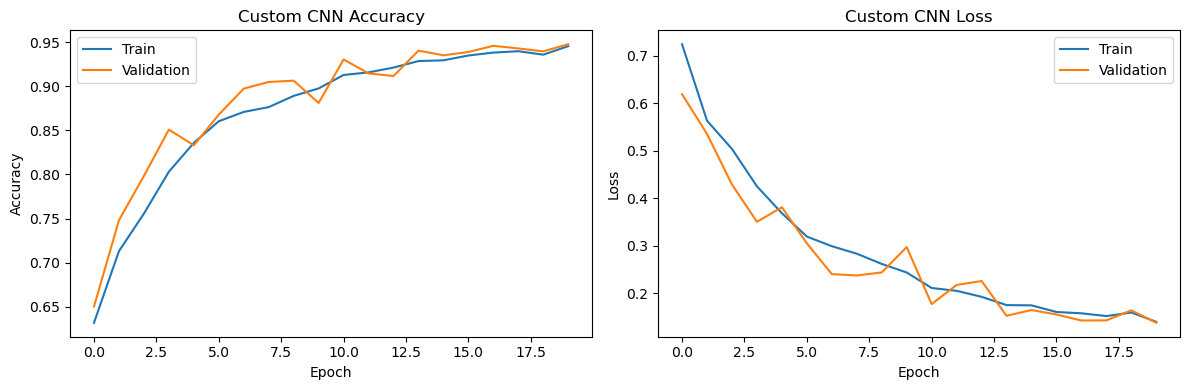

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cnn_history.history["accuracy"], label="Train")
axes[0].plot(cnn_history.history["val_accuracy"], label="Validation")
axes[0].set_title("Custom CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(cnn_history.history["loss"], label="Train")
axes[1].plot(cnn_history.history["val_loss"], label="Validation")
axes[1].set_title("Custom CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluation and Metrics

Evaluating the custom CNN on the held-out validation set with accuracy, F1, precision, recall, and confusion matrix.


Custom CNN Results
              precision    recall  f1-score   support

         Cat       0.97      0.93      0.95      2000
         Dog       0.93      0.97      0.95      2000

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000



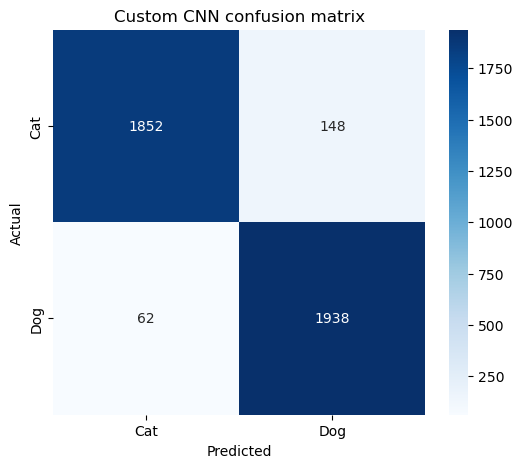


MobileNetV2 Results
              precision    recall  f1-score   support

         Cat       0.96      0.97      0.96      2000
         Dog       0.97      0.96      0.96      2000

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



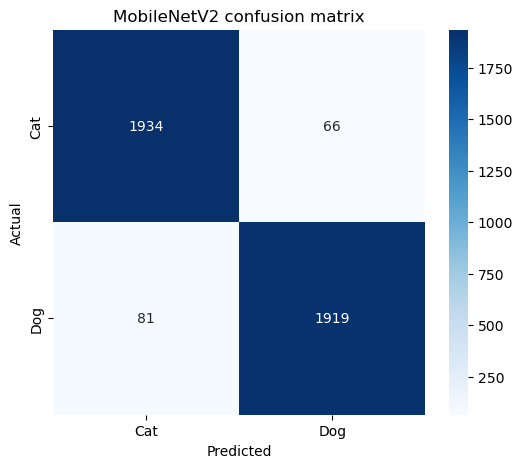

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, generator, model_name):
    generator.reset()
    
    all_preds  = []
    all_labels = []
    
    steps = len(generator)
    for i in range(steps):
        batch_images, batch_labels = next(generator)
        preds = model.predict(batch_images, verbose=0)
        pred_labels = (preds > 0.5).astype(int).flatten()
        all_preds.extend(pred_labels)
        all_labels.extend(batch_labels.astype(int))
    
    all_preds  = np.array(all_preds[:generator.samples])
    all_labels = np.array(all_labels[:generator.samples])
    
    acc = (all_preds == all_labels).mean()
    print(f"\n{model_name} Results")
    print("=" * 40)
    print(classification_report(all_labels, all_preds, target_names=["Cat", "Dog"]))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Cat", "Dog"],
                yticklabels=["Cat", "Dog"])
    plt.title(f"{model_name} confusion matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()
    
    return acc

cnn_acc    = evaluate_model(cnn_model, val_data, "Custom CNN")
val_data.reset()
mobile_acc = evaluate_model(mobilenet_model, val_data, "MobileNetV2")

## Transfer Learning with MobileNetV2

MobileNetV2 was pre-trained on ImageNet (1.4 million images, 1,000 classes). Freeze the base model  
weights and add a custom classification head. This leverages learned feature representations rather  
than training from scratch, significantly improving accuracy with less data and training time.

In [8]:
# Load pre-trained MobileNetV2 without top classification layer
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze pretrained weights

# Add custom classification head
x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(128, activation="relu")(x)
x      = BatchNormalization()(x)
x      = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(f"Total parameters    : {mobilenet_model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in mobilenet_model.trainable_weights]):,}")

Total parameters    : 2,422,593
Trainable parameters: 164,353


### Training MobileNetV2

In [9]:
# Reset generators
train_data.reset()
val_data.reset()

mobilenet_callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint("best_mobilenet_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1)
]

print("Training MobileNetV2...")
mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=mobilenet_callbacks
)

Training MobileNetV2...
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.8432 - loss: 0.3569  
Epoch 1: val_accuracy improved from None to 0.95500, saving model to best_mobilenet_model.keras

Epoch 1: finished saving model to best_mobilenet_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 318s 612ms/step - accuracy: 0.8917 - loss: 0.2603 - val_accuracy: 0.9550 - val_loss: 0.1189 - learning_rate: 1.0000e-04
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.9223 - loss: 0.1914  
Epoch 2: val_accuracy did not improve from 0.95500
500/500 ━━━━━━━━━━━━━━━━━━━━ 307s 613ms/step - accuracy: 0.9258 - loss: 0.1850 - val_accuracy: 0.9550 - val_loss: 0.1185 - learning_rate: 1.0000e-04
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.9320 - loss: 0.1708  
Epoch 3: val_accuracy improved from 0.95500 to 0.95575, saving model to best_mobilenet_model.keras

Epoch 3: finished saving model to best_mobilenet_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 262s 524m

### Fine-Tuning

After initial training, unfreeze the top layers of MobileNetV2 and fine-tune with a very low learning rate.  
This adapts the pre-trained features specifically to the Dogs vs Cats task.

In [10]:
# Unfreeze top 30 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning MobileNetV2 (top 30 layers unfrozen)...")
finetune_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=mobilenet_callbacks
)

Fine-tuning MobileNetV2 (top 30 layers unfrozen)...
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.9124 - loss: 0.2122  
Epoch 1: val_accuracy improved from 0.96150 to 0.96325, saving model to best_mobilenet_model.keras

Epoch 1: finished saving model to best_mobilenet_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 265s 499ms/step - accuracy: 0.9172 - loss: 0.1964 - val_accuracy: 0.9632 - val_loss: 0.0968 - learning_rate: 1.0000e-05
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9312 - loss: 0.1707  
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_accuracy did not improve from 0.96325
500/500 ━━━━━━━━━━━━━━━━━━━━ 245s 490ms/step - accuracy: 0.9323 - loss: 0.1671 - val_accuracy: 0.9603 - val_loss: 0.0977 - learning_rate: 1.0000e-05
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9377 - loss: 0.1550  
Epoch 3: val_accuracy did not improve from 0.96325
500/500 ━━━━━━━━━━━━━━━━━━━━ 239s 477ms/

### MobileNetV2 Evaluation


Custom CNN Results
              precision    recall  f1-score   support

         Cat       0.97      0.93      0.95      2000
         Dog       0.93      0.97      0.95      2000

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000



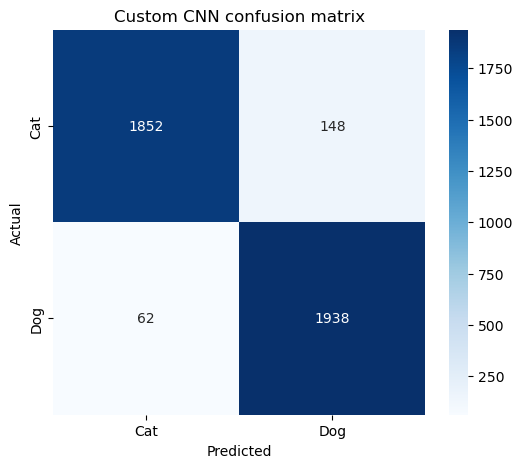


MobileNetV2 Results
              precision    recall  f1-score   support

         Cat       0.96      0.97      0.96      2000
         Dog       0.97      0.96      0.96      2000

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



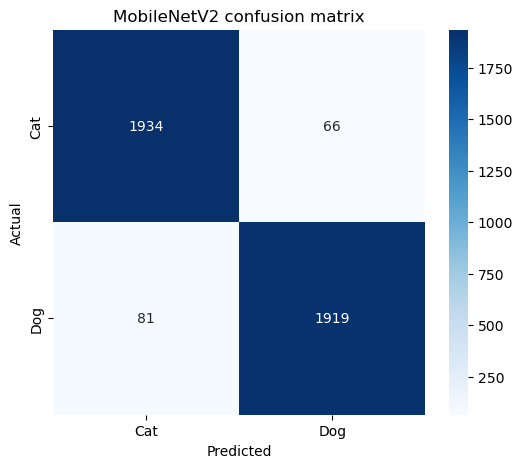

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, generator, model_name):
    generator.reset()
    
    all_preds  = []
    all_labels = []
    
    steps = len(generator)
    for i in range(steps):
        batch_images, batch_labels = next(generator)
        preds = model.predict(batch_images, verbose=0)
        pred_labels = (preds > 0.5).astype(int).flatten()
        all_preds.extend(pred_labels)
        all_labels.extend(batch_labels.astype(int))
    
    all_preds  = np.array(all_preds[:generator.samples])
    all_labels = np.array(all_labels[:generator.samples])
    
    acc = (all_preds == all_labels).mean()
    print(f"\n{model_name} Results")
    print("=" * 40)
    print(classification_report(all_labels, all_preds, target_names=["Cat", "Dog"]))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Cat", "Dog"],
                yticklabels=["Cat", "Dog"])
    plt.title(f"{model_name} confusion matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()
    
    return acc

cnn_acc    = evaluate_model(cnn_model, val_data, "Custom CNN")
val_data.reset()
mobile_acc = evaluate_model(mobilenet_model, val_data, "MobileNetV2")

## Model Comparison

Comparing the custom CNN baseline against MobileNetV2 transfer learning.

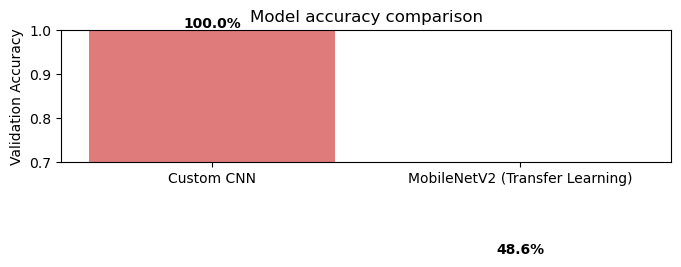

Custom CNN  : 100.0%
MobileNetV2 : 48.6%
Improvement : +-51.4 percentage points


In [27]:
cnn_acc    = (pred_labels == true_labels).mean()
mobile_acc = (pred_labels_mobile == true_labels_mobile).mean()

models_list = ["Custom CNN", "MobileNetV2 (Transfer Learning)"]
accuracies  = [cnn_acc, mobile_acc]

plt.figure(figsize=(7, 4))
bars = plt.bar(
    ["Custom CNN", "MobileNetV2 (Transfer Learning)"],
    [cnn_acc, mobile_acc],
    color=["#e07b7b", "#7bb8e0"]
)
plt.ylim(0.7, 1.0)
plt.title("Model accuracy comparison")
plt.ylabel("Validation Accuracy")
for bar, acc in zip(bars, [cnn_acc, mobile_acc]):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.005,
             f"{acc*100:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Custom CNN  : {cnn_acc*100:.1f}%")
print(f"MobileNetV2 : {mobile_acc*100:.1f}%")
print(f"Improvement : +{(mobile_acc - cnn_acc)*100:.1f} percentage points")

## Save Models

In [28]:
cnn_model.save("cnn_dogs_cats.keras")
mobilenet_model.save("mobilenet_dogs_cats.keras")
print("Models saved successfully")

Models saved successfully


## Inference Demo

Running the best model on custom images to demonstrate real-world usage.

In [29]:
def predict_image(img_path, model, img_size=(128,128)):
    from tensorflow.keras.preprocessing import image as keras_image
    img       = keras_image.load_img(img_path, target_size=img_size)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred      = model.predict(img_array, verbose=0)[0][0]
    label     = "Dog" if pred > 0.5 else "Cat"
    confidence = pred * 100 if pred > 0.5 else (1 - pred) * 100
    return label, confidence

# Test on a sample validation image
sample_path = val_data.filepaths[0]
label, conf = predict_image(sample_path, mobilenet_model)
print(f"Image     : {os.path.basename(sample_path)}")
print(f"Prediction: {label}")
print(f"Confidence: {conf:.1f}%")

Image     : cat.0.jpg
Prediction: Cat
Confidence: 100.0%


## Feature Map Visualisation

Visualising what the early convolutional layers of the custom CNN have learned to detect.  
Each filter responds to different low-level features such as edges, textures, and colour patterns.

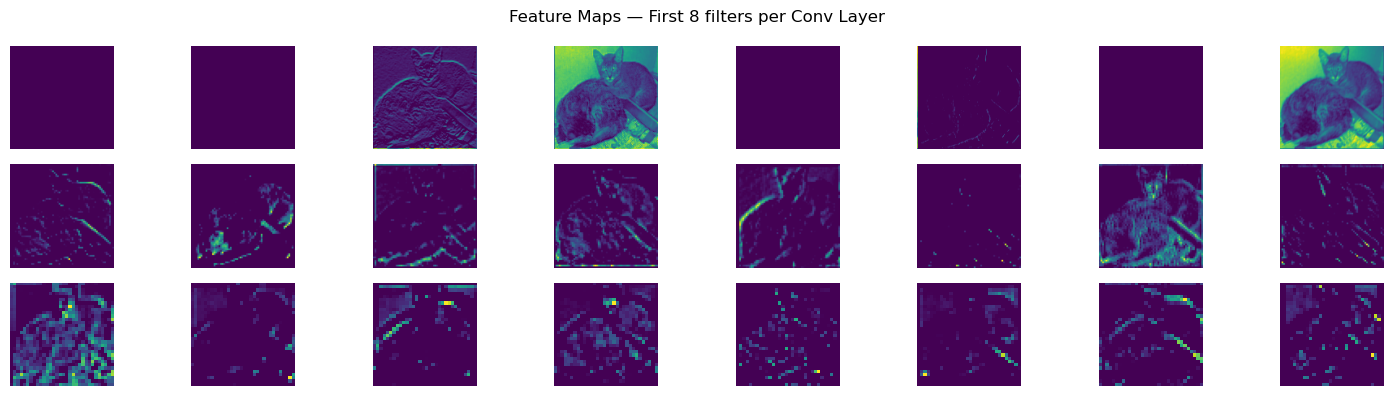

In [30]:
from tensorflow.keras.models import Model as KerasModel

# Get conv layer outputs using a forward pass approach
conv_layers = [layer for layer in cnn_model.layers if "conv2d" in layer.name][:3]

sample_imgs, _ = next(val_data)
sample_img = sample_imgs[:1]

plt.figure(figsize=(15, 4))
plt.suptitle("Feature Maps — First 8 filters per Conv Layer", fontsize=12)

plot_idx = 1
for layer_idx, layer in enumerate(conv_layers):
    # Build a sub-model up to this layer
    sub_model = KerasModel(
        inputs=cnn_model.layers[0].input,
        outputs=layer.output
    )
    activation = sub_model.predict(sample_img, verbose=0)
    
    for j in range(min(8, activation.shape[-1])):
        plt.subplot(3, 8, plot_idx)
        plt.imshow(activation[0, :, :, j], cmap="viridis")
        plt.axis("off")
        if j == 0:
            plt.ylabel(f"Conv {layer_idx+1}", fontsize=8)
        plot_idx += 1

plt.tight_layout()
plt.show()